# Explore here

### Leemos los datos del csv

In [19]:
# Your code here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


total_data = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv")
total_data.head()

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


### Construcción de la serie temporal

In [20]:
import pandas as pd
# primero convertimos la columna "date" a formato datetime 
# y luego la establecemos como índice del DataFrame, 
# para que sea más fácil trabajar con series temporales
total_data["date"] = pd.to_datetime(total_data["date"])
total_data = total_data.set_index("date")

# Luego extraemos la columna "sales" como una serie temporal
# que es la variable que queremos analizar
ts = total_data["sales"]
ts.head()

date
2022-09-03 17:10:08.079328    55.292157
2022-09-04 17:10:08.079328    53.803211
2022-09-05 17:10:08.079328    58.141693
2022-09-06 17:10:08.079328    64.530899
2022-09-07 17:10:08.079328    66.013633
Name: sales, dtype: float64

### Visualizaremos la serie

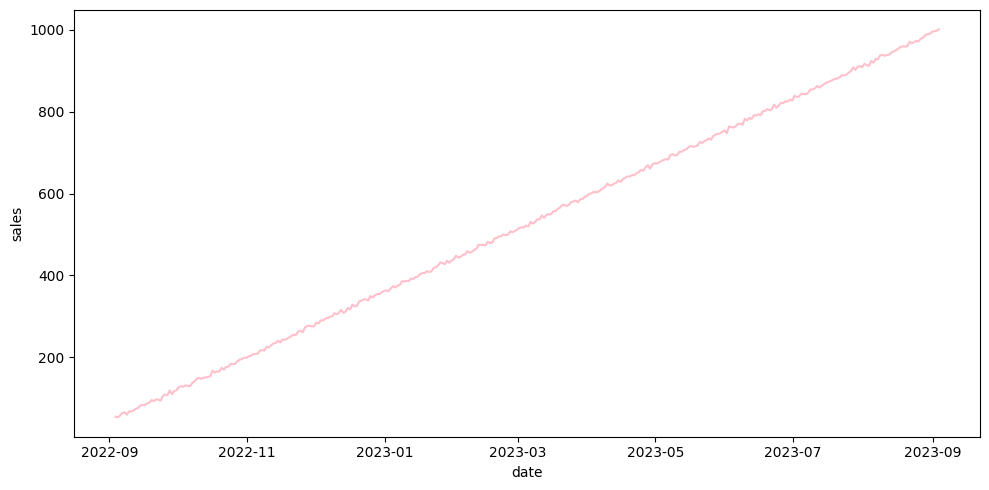

In [21]:
import matplotlib.pyplot as plt

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = ts, color = "pink")

plt.tight_layout()

plt.show()

La serie temporal muestra una tendencia ascendente muy clara y sostenida. La subida es prácticamente lineal a lo largo de todo el año. A simple vista no se aprecia estacionalidad marcada ni outliers evidentes, aunque sí existe una ligera variabilidad (pequeñas oscilaciones sobre la tendencia principal) que habrá que cuantificar con la descomposición.

### analiza la serie temporal

#### ¿Cuál es el tensor de la serie temporal?

In [ ]:
# Comprobnaremos la frecuencia de la serie temporal:
# primero  vemos la diferencia entre fechas consecutivas para entender la frecuencia de los datos
print("Diferencia entre fechas consecutivas:", ts.index[1] - ts.index[0])
# las observaciones son diarias, por lo que la frecuencia es diaria
print("Nº total de observaciones:", len(ts))
# Y cuando comienza y termina la serie temporal, 
# lo que nos da una idea del período de tiempo que abarca la serie
print("Fecha inicio:", ts.index[0])
print("Fecha fin:", ts.index[-1])

Diferencia entre fechas consecutivas: 1 days 00:00:00
Nº total de observaciones: 366
Fecha inicio: 2022-09-03 17:10:08.079328
Fecha fin: 2023-09-03 17:10:08.079328


Haciendo estas preguntas vemos que el tensor es diario, por que estan separados por un dia de la siguiente, durante 1 año completo 

¿Cuál es la tendencia?

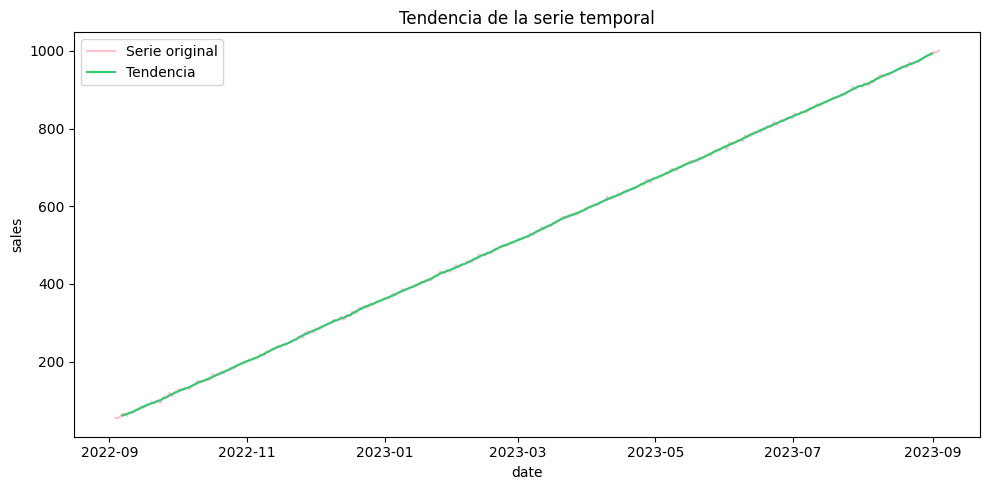

In [26]:
from statsmodels.tsa.seasonal import seasonal_decompose

#PAra acceder a la tendencia de la serie temporal, 
# necesitamos realizar una descomposición de la serie temporal utilizando 
# la función seasonal_decompose de la biblioteca statsmodels.
decomposition = seasonal_decompose(ts, period=7)
trend = decomposition.trend

fig, axis = plt.subplots(figsize=(10, 5))
sns.lineplot(data=ts, label="Serie original", color="pink")
sns.lineplot(data=trend, label="Tendencia", color="#2ecc71")  # verde para distinguir
plt.title("Tendencia de la serie temporal")
plt.tight_layout()
plt.show()

La serie original (rosa) representa los datos reales de ventas día a día, con todas sus pequeñas fluctuaciones. La tendencia (verde) es la línea suavizada que extrae la dirección general de los datos eliminando el ruido y la estacionalidad.
Ambas líneas aparecen casi pegadas porque la serie es extremadamente lineal — el crecimiento es tan constante y el ruido tan pequeño que la tendencia calculada coincide casi punto por punto con los datos reales. Esto es una buena señal: significa que las ventas han crecido de forma muy estable y predecible a lo largo del año, sin grandes irregularidades ni cambios bruscos de comportamiento.

es decir: son casi iguale s por que nuestra serie de ventas tiene miuy poco ruido , las ventas suben de manera muy graudial y sin grandes picos, significa que el crecimiento del negocio es constante y predecible.

### ¿Es estacionaria?

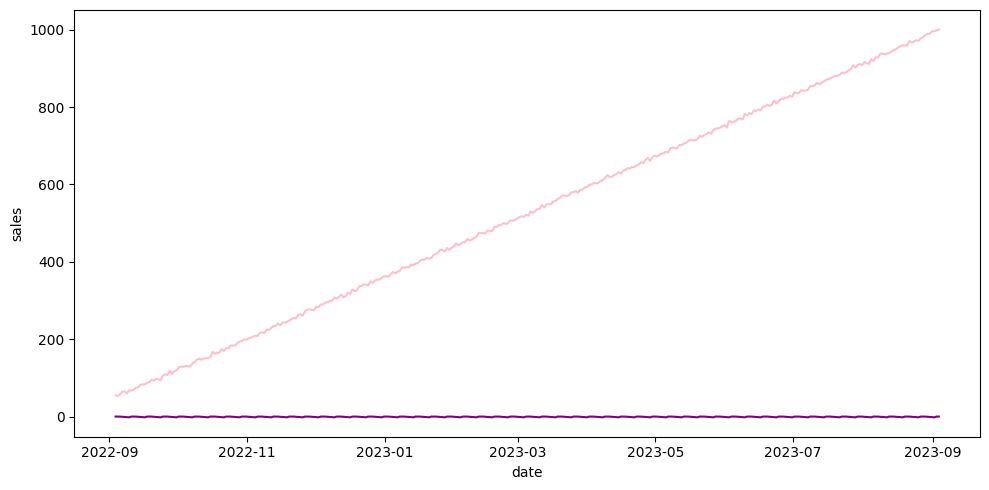

In [29]:
seasonal = decomposition.seasonal

fig, axis = plt.subplots(figsize=(10, 5))

sns.lineplot(data=ts, color="pink")
sns.lineplot(data=seasonal, color="purple")

plt.tight_layout()

plt.show()

La línea morada representa la estacionalidad y se mantiene prácticamente plana cerca del 0 a lo largo de todo el período. Esto indica que el componente estacional es muy pequeño y casi insignificante comparado con la escala de las ventas (que llegan a 1000). La serie no tiene patrones estacionales relevantes — su comportamiento está dominado casi por completo por la tendencia ascendente.

In [ ]:
from statsmodels.tsa.stattools import adfuller
# Aqui definimos la función test_stationarity que realiza la prueba de Dickey-Fuller 
# para evaluar si una serie temporal es estacionaria o no.
def test_stationarity(timeseries):
    print("Resultados de la prueba de Dickey-Fuller:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(dftest[0:4], index=["Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"])
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    return dfoutput

test_stationarity(ts)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                   0.545414
p-value                          0.986190
#Lags Used                      13.000000
Number of Observations Used    352.000000
Critical Value (1%)             -3.449065
Critical Value (5%)             -2.869786
Critical Value (10%)            -2.571163
dtype: float64

El p-value obtenido es 0.986, muy por encima del umbral de 0.05. Esto significa que no podemos rechazar la hipótesis nula → la serie NO es estacionaria. El Test Statistic (0.545) es además mayor que todos los valores críticos, lo que refuerza la conclusión. Tiene todo el sentido: una serie con una tendencia ascendente tan pronunciada tiene su media cambiando continuamente con el tiempo, lo cual es precisamente lo que hace que no sea estacionaria. 

### ¿Existe variabilidad o presencia de ruido?

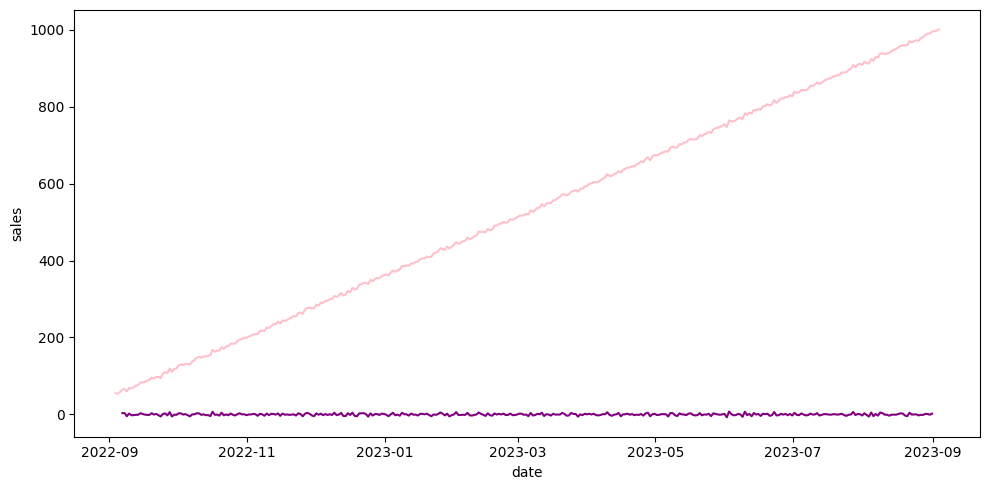

In [33]:
residual = decomposition.resid

fig, axis = plt.subplots(figsize=(10, 5))

sns.lineplot(data=ts, color="pink")
sns.lineplot(data=residual, color="purple")

plt.tight_layout()

plt.show()

La variabilidad implica el estudio de los residuos: cómo fluctúan los datos una vez se ha extraído la tendencia y la estacionalidad. Se aprecia cierta irregularidad al inicio y al final del periodo, lo que sugiere que el modelo de descomposición capta bien el patrón central pero deja algo de ruido en los extremos.

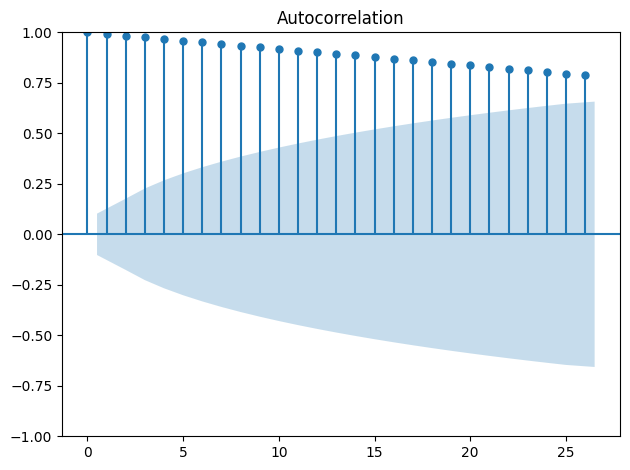

In [32]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(ts)

plt.tight_layout()

plt.show()

La autocorrelación mide la correlación de la serie consigo misma en distintos retardos (lags). Se aprecia una correlación significativa y decreciente a lo largo de los retardos, lo que confirma que los valores pasados influyen en los futuros y que la serie tiene una estructura temporal aprovechable para el modelado ARIMA.

que sea descendiente quiere decir : que el día de ayer influye más en hoy que lo que pasó hace 30 días. Las ventas de ayer te dicen mucho sobre las de hoy, pero las de hace un mes ya apenas influyen. Que sea decreciente y no que caiga de golpe a cero confirma que tiene estructura temporal aprovechable, es decir, que tiene sentido usar ARIMA.

## Paso 3: Entrenamiento del modelo

dividimos en train y test 

In [36]:
from sklearn.model_selection import train_test_split

# Dividimos la serie temporal en entrenamiento (80%) y prueba (20%)
# shuffle=False es obligatorio para respetar el orden temporal, 
# sirve para evitar que los datos se mezclen aleatoriamente, 
# lo cual es crucial en series temporales para mantener la secuencia temporal.
train, test = train_test_split(ts, test_size=0.2, shuffle=False)

Transformamos el conjunto de entrenamiento a estacionario

In [37]:
# aqui usamos la función test_stationarity para comprobar si la serie temporal es estacionaria o no,
# para ello aplicamos una diferenciación a la serie temporal original utilizando el método diff() de pandas,
# lo que nos da la serie temporal diferenciada, y luego eliminamos los valores nulos que se generan debido a la diferenciación con dropna().    
ts_stationary = ts.diff().dropna()

test_stationarity(ts_stationary)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                -9.430263e+00
p-value                        5.212954e-16
#Lags Used                     1.200000e+01
Number of Observations Used    3.520000e+02
Critical Value (1%)           -3.449065e+00
Critical Value (5%)           -2.869786e+00
Critical Value (10%)          -2.571163e+00
dtype: float64

El p-value es 5.21, muy por debajo del umbral de 0.05. Además, el Test Statistic (-9.43) es mucho menor que todos los valores críticos (1%, 5% y 10%). Esto significa que rechazamos la hipótesis nula y confirmamos que la serie diferenciada SÍ es estacionaria. La transformación con .diff() ha funcionado correctamente y el modelo ARIMA ya puede entrenarse sobre ella.

Aplicamos el metodo ARIMA automatico

In [ ]:
from pmdarima import auto_arima
# un vez ya tenemos la serie temporal estacionaria, 
# podemos entrenar un modelo ARIMA utilizando la función auto_arima 
model = auto_arima(ts_stationary, seasonal=True, trace=True, m=7)
model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=inf, Time=2.17 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=2096.542, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=1966.396, Time=0.09 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=inf, Time=0.32 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=2209.657, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[7] intercept   : AIC=1970.972, Time=0.02 sec
 ARIMA(1,0,0)(2,0,0)[7] intercept   : AIC=1968.120, Time=0.21 sec
 ARIMA(1,0,0)(1,0,1)[7] intercept   : AIC=1968.220, Time=0.16 sec
 ARIMA(1,0,0)(0,0,1)[7] intercept   : AIC=1966.919, Time=0.06 sec
 ARIMA(1,0,0)(2,0,1)[7] intercept   : AIC=1965.376, Time=0.52 sec
 ARIMA(1,0,0)(2,0,2)[7] intercept   : AIC=1965.211, Time=0.66 sec
 ARIMA(1,0,0)(1,0,2)[7] intercept   : AIC=1963.937, Time=0.47 sec
 ARIMA(1,0,0)(0,0,2)[7] intercept   : AIC=1967.822, Time=0.16 sec
 ARIMA(0,0,0)(1,0,2)[7] intercept   : AIC=2094.918, Time=0.42 sec
 ARIMA(2,0,0)(1,0,2)[7] intercept   : AIC=1

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                  365
Model:             SARIMAX(4, 0, 1)x(0, 0, 1, 7)   Log Likelihood                -912.046
Date:                           Thu, 28 May 2026   AIC                           1840.093
Time:                                   19:45:29   BIC                           1871.292
Sample:                               09-04-2022   HQIC                          1852.491
                                    - 09-03-2023                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.3920      0.301      7.941      0.000       1.802       2.982
ar.L1         -0.0338      0.052     -0.651      0.515      -0.136       0.068
ar.L2          0.0755      0.057      1.315      0.188      -0.037       0.188
ar.L3          0.0750      0.053      1.402      0.161      -0.030       0.180
ar.L4         -0.0367      0.051     -0.718      0.473      -0.137       0.063
ma.L1         -0.9821      0.020    -50.306      0.000      -1.020      -0.944
ma.S.L7        0.1389      0.053      2.643      0.008       0.036       0.242
sigma2         8.4862      0.671     12.651      0.000       7.172       9.801
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):                 0.87
Prob(Q):                              0.81   Prob(JB):                         0.65
Heteroskedasticity (H):               0.87   Skew:                             0.07
Prob(H) (two-sided):                  0.45   Kurtosis:                         2.80
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Predicción

In [41]:
# Con el modelo entrenado, 
# podemos hacer predicciones para los próximos 10 períodos utilizando 
# el método predict() del modelo ARIMA.
forecast = model.predict(10)
forecast

2023-09-04 17:10:08.079328    1.937854
2023-09-05 17:10:08.079328    2.736329
2023-09-06 17:10:08.079328    2.340073
2023-09-07 17:10:08.079328    2.892647
2023-09-08 17:10:08.079328    2.468718
2023-09-09 17:10:08.079328    2.358579
2023-09-10 17:10:08.079328    2.663538
2023-09-11 17:10:08.079328    2.472653
2023-09-12 17:10:08.079328    2.595951
2023-09-13 17:10:08.079328    2.604267
Freq: D, dtype: float64

El modelo predice una variación diaria de ventas estable y positiva para los 10 días siguientes, 
con valores que oscilan entre 1.94 y 2.89 unidades de incremento respecto al día anterior. 
Esto es coherente con la tendencia ascendente que se observó en la serie original: 
el modelo ha aprendido que las ventas tienden a crecer ligeramente día a día, 
y proyecta esa dinámica hacia el futuro de forma consistente y sin grandes fluctuaciones, 
lo que da confianza en la estabilidad del negocio a corto plazo.

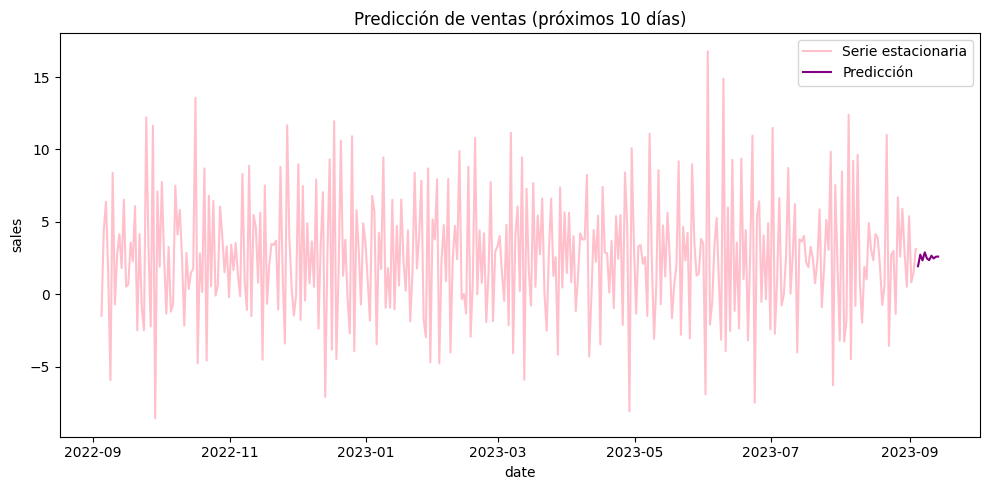

In [45]:
import matplotlib.pyplot as plt

fig, axis = plt.subplots(figsize=(10, 5))

sns.lineplot(data=ts_stationary, label="Serie estacionaria", color="pink")
sns.lineplot(data=forecast, color="purple", label="Predicción")

plt.title("Predicción de ventas (próximos 10 días)")
plt.tight_layout()
plt.show()

En el gráfico se puede observar la serie estacionaria (rosa) a lo largo de todo el periodo de estudio, 
desde septiembre de 2022 hasta septiembre de 2023.
Al final de la serie, en morado, aparecen los 10 días predichos. 

### Guardar el modelo

In [43]:
import pickle
import os
import os
# cuando guardamos un modelo con pickle, 
# es importante asegurarnos de que el directorio donde queremos guardarlo exista,
os.makedirs("models", exist_ok=True)

# entonces podemos guardar el modelo entrenado en un archivo utilizando pickle.dump(),
with open("models/arima_sales_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Modelo guardado correctamente en models/arima_sales_model.pkl")

Modelo guardado correctamente en models/arima_sales_model.pkl
